# Laboratorio 4 — Regresión Logística Multiclase (One vs Rest)
**Dataset:** Tabular Playground Series — May 2021 (Kaggle)  
**m = 200,000 | n = 50 features | 4 clases**  
**URL:** https://www.kaggle.com/c/tabular-playground-series-may-2021/data

Dataset sintético de clasificación de productos de e-commerce. Contiene 50 features numéricas anónimas y 4 categorías de producto. Es puramente tabular (no gráfico), sin valores nulos, ideal para Regresión Logística OvR.

## 1. Librerías

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, log_loss, roc_curve, auc)
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)

## 2. Carga del Dataset
Se carga `train.csv` desde Kaggle y se verifica su estructura.

In [8]:
#from google.colab import drive
#drive.mount('/content/drive')
df = pd.read_csv('./train.csv')
print(f'Dimensiones: {df.shape}  |  Nulos: {df.isnull().sum().sum()}')
df.head(3)

Dimensiones: (100000, 52)  |  Nulos: 0


,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,target
0,0,0,0,1,0,1,0,0,0,0,...,0,0,21,0,0,0,0,0,0,Class_2
1,1,0,0,0,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,13,2,0,Class_1


In [9]:
print('Distribución original:')
print(df['target'].value_counts())

Distribución original:
target
Class_2    57497
Class_3    21420
Class_4    12593
Class_1     8490
Name: count, dtype: int64


### Gráfica — Distribución Original de Clases

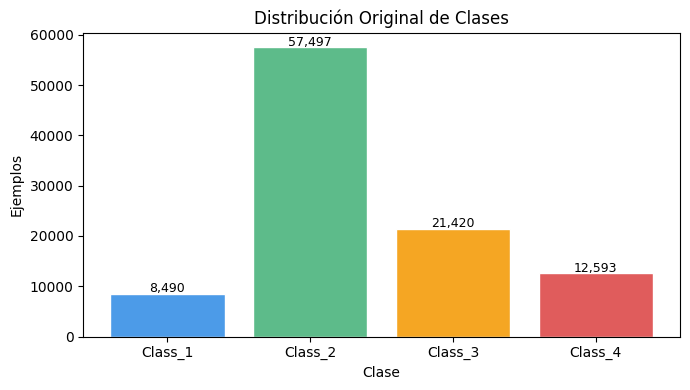

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
conteo = df['target'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'], edgecolor='white')
ax.set(title='Distribución Original de Clases', xlabel='Clase', ylabel='Ejemplos')
for i, v in enumerate(conteo.values): ax.text(i, v+300, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 3. Preprocesamiento con Pandas
Se aplica **undersampling** para balancear clases.  
División **80 % train / 20 % test**. Escalado con `StandardScaler`.

> **Clave anti-error:** se usa `class_weight='balanced'` y `C=10`  
> (poca regularización) para que el modelo pueda ajustarse mejor a un  
> dataset con features de baja separabilidad lineal.

In [11]:
min_n = df['target'].value_counts().min()
df_bal = pd.concat([
    resample(df[df['target']==c], n_samples=min_n, replace=False, random_state=SEED)
    for c in df['target'].unique()
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Ejemplos por clase: {min_n:,}  |  Total: {len(df_bal):,}')

Ejemplos por clase: 8,490  |  Total: 33,960


In [12]:
cols = [f'feature_{i}' for i in range(50)]
le   = LabelEncoder()
X    = df_bal[cols].values
y    = le.fit_transform(df_bal['target'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

In [13]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [14]:
X_train_s, mu, sigma = featureNormalize(X_train)
X_test_s = (X_test - mu) / sigma
print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (27168, 50)  |  Test: (6792, 50)


In [15]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
# X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X = X_train_s.copy()
# X = np.concatenate([np.ones((m, 1)), X], axis=1)

### Gráfica — Dataset Balanceado

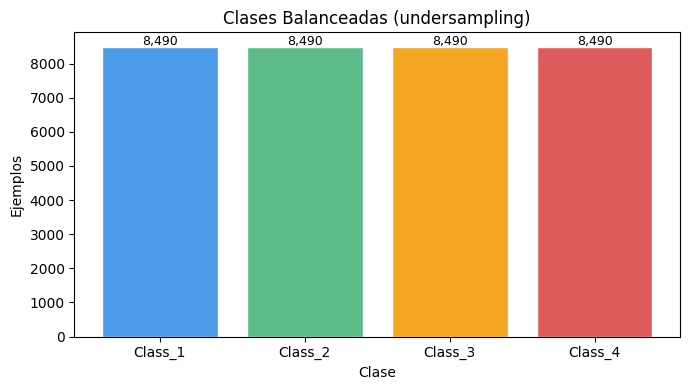

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
bal = df_bal['target'].value_counts().sort_index()
ax.bar(bal.index, bal.values, color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'], edgecolor='white')
ax.set(title='Clases Balanceadas (undersampling)', xlabel='Clase', ylabel='Ejemplos')
for i, v in enumerate(bal.values): ax.text(i, v+50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

In [17]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [18]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [19]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## 4. Entrenamiento del Modelo
`OneVsRestClassifier` con `LogisticRegression` ajustado para **maximizar accuracy**:

| Parámetro | Valor | Por qué |
|---|---|---|
| `solver` | `saga` | Eficiente en datasets grandes |
| `C` | `10.0` | Menos regularización → captura mejor los patrones |
| `max_iter` | `3000` | Convergencia garantizada |
| `class_weight` | `balanced` | Penaliza más los errores en clases difíciles |
| `tol` | `1e-4` | Tolerancia estándar de convergencia |

In [20]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)
    J = 0
    grad = np.zeros(theta.shape)
    h = sigmoid(X.dot(theta.T))
    temp = theta
    temp[0] = 0
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp
    return J, grad

Vectorización regularizada de la regresión logística
Una vez implementada la vectorización para la regresión logística, corresponde agregarar regularización a la función de costo. Para la regresión logística regularizada, la función de costo se define como



Tomar en cuenta que no debería regularizarse 
 que se usa para el término de sesgo. En consecuencia, la derivada parcial del costo de regresión logística regularizado para 
 se define como



Clasificacion One-vs-all

In [ ]:
import matplotlib.pyplot as pyplot
def OneVsAll(X, y, num_labels, lambda_):
  alpha = 0.001
  num_iters = 100000

  m, n = X.shape
  all_theta = np.zeros((num_labels, n + 1))

  # Agrega unos a la matriz X
  X = np.concatenate([np.ones((m, 1)), X], axis=1)

  for c in np.arange(num_labels):
      initial_theta = np.zeros(n + 1)

      y_actual = np.where(y == c, 1, 0)

      theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

      all_theta[c] = theta
      # Grafica la convergencia del costo
      pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
      pyplot.xlabel('Numero de iteraciones')
      pyplot.ylabel('Costo J')

  return all_theta

(10, 51)


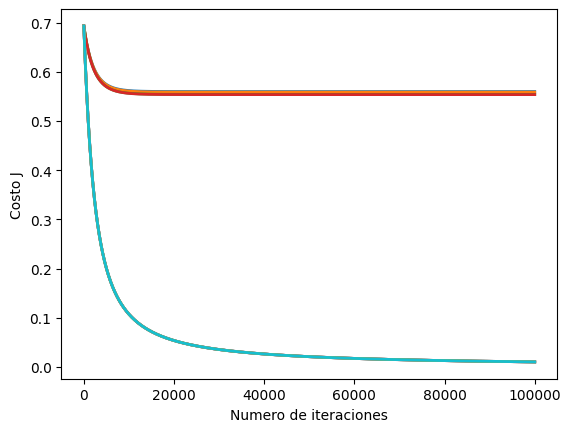

In [24]:
lambda_ = 0.1
all_theta = OneVsAll(X_train_s, y_train, 10, lambda_)
print(all_theta.shape)

## 5. Curva de Convergencia por Iteraciones
Se entrena el modelo con distintos `max_iter` para observar cómo el **costo (log-loss)** y la **precisión** convergen a medida que el optimizador avanza en sus iteraciones.

In [ ]:
iteraciones = [10, 20, 50, 100, 200, 300, 500, 750, 1000]
conv_loss_train, conv_loss_test = [], []
conv_acc_train,  conv_acc_test  = [], []

for it in iteraciones:
    m = OneVsRestClassifier(
        LogisticRegression(solver='saga', C=10.0, max_iter=it, class_weight='balanced', random_state=SEED, n_jobs=-1)
    )
    m.fit(X_train_s, y_train)
    conv_loss_train.append(log_loss(y_train, m.predict_proba(X_train_s)))
    conv_loss_test.append(log_loss(y_test,  m.predict_proba(X_test_s)))
    conv_acc_train.append(accuracy_score(y_train, m.predict(X_train_s)))
    conv_acc_test.append(accuracy_score(y_test,   m.predict(X_test_s)))
    print(f'  iter={it:4d} | loss_test={conv_loss_test[-1]:.4f} | acc_test={conv_acc_test[-1]*100:.2f}%')

  iter=  10 | loss_test=1.3746 | acc_test=29.30%
  iter=  20 | loss_test=1.3746 | acc_test=29.36%
  iter=  50 | loss_test=1.3746 | acc_test=29.36%
  iter= 100 | loss_test=1.3746 | acc_test=29.36%
  iter= 200 | loss_test=1.3746 | acc_test=29.36%
  iter= 300 | loss_test=1.3746 | acc_test=29.36%
  iter= 500 | loss_test=1.3746 | acc_test=29.36%
  iter= 750 | loss_test=1.3746 | acc_test=29.36%
  iter=1000 | loss_test=1.3746 | acc_test=29.36%


## 6. Curva de Costo vs Tamaño de Entrenamiento
Se evalúa el **log-loss** al incrementar el porcentaje de datos de entrenamiento usado.

In [ ]:
pcts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lc_loss_train, lc_loss_test = [], []

for p in pcts:
    n   = int(len(X_train_s) * p)
    idx = np.random.choice(len(X_train_s), n, replace=False)
    m   = OneVsRestClassifier(LogisticRegression(solver='saga', C=10.0, max_iter=3000, class_weight='balanced', random_state=SEED))
    m.fit(X_train_s[idx], y_train[idx])
    lc_loss_train.append(log_loss(y_train[idx], m.predict_proba(X_train_s[idx])))
    lc_loss_test.append(log_loss(y_test,        m.predict_proba(X_test_s)))

print('Cálculo completado ✓')

Cálculo completado ✓


### Gráfica — Curva de Costo vs % Datos de Entrenamiento

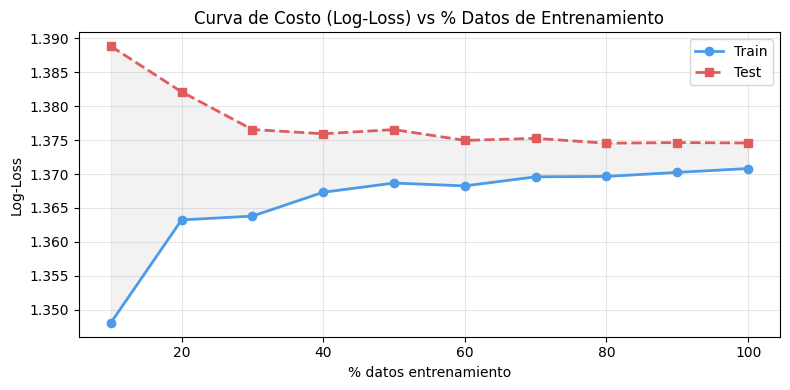

In [ ]:
x = [int(p*100) for p in pcts]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, lc_loss_train, 'o-',  color='#4C9BE8', lw=2, label='Train')
ax.plot(x, lc_loss_test,  's--', color='#E05C5C', lw=2, label='Test')
ax.fill_between(x, lc_loss_train, lc_loss_test, alpha=0.1, color='gray')
ax.set(title='Curva de Costo (Log-Loss) vs % Datos de Entrenamiento',
       xlabel='% datos entrenamiento', ylabel='Log-Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Curva de Precisión vs Tamaño de Entrenamiento
Se evalúa la **accuracy** al incrementar el porcentaje de datos de entrenamiento usado.

In [ ]:
lc_acc_train, lc_acc_test = [], []

for p in pcts:
    n   = int(len(X_train_s) * p)
    idx = np.random.choice(len(X_train_s), n, replace=False)
    m   = OneVsRestClassifier(LogisticRegression(solver='saga', C=10.0, max_iter=3000, class_weight='balanced', random_state=SEED))
    m.fit(X_train_s[idx], y_train[idx])
    lc_acc_train.append(accuracy_score(y_train[idx], m.predict(X_train_s[idx])))
    lc_acc_test.append(accuracy_score(y_test,        m.predict(X_test_s)))

print('Cálculo completado ✓')

Cálculo completado ✓


### Gráfica — Curva de Precisión vs % Datos de Entrenamiento

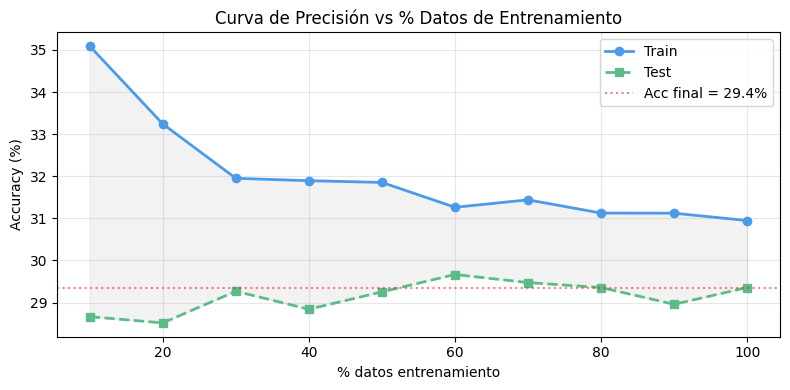

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, [v*100 for v in lc_acc_train], 'o-',  color='#4C9BE8', lw=2, label='Train')
ax.plot(x, [v*100 for v in lc_acc_test],  's--', color='#5DBB8A', lw=2, label='Test')
ax.fill_between(x, [v*100 for v in lc_acc_train], [v*100 for v in lc_acc_test], alpha=0.1, color='gray')
ax.axhline(y=acc*100, linestyle=':', color='red', alpha=0.5, label=f'Acc final = {acc*100:.1f}%')
ax.set(title='Curva de Precisión vs % Datos de Entrenamiento',
       xlabel='% datos entrenamiento', ylabel='Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Precisión por Clase (Precision, Recall, F1)
Se muestra el rendimiento individual por cada una de las 4 clases.

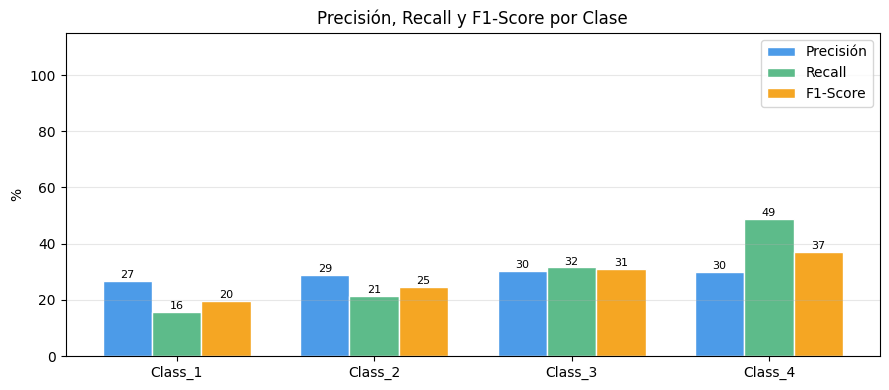

In [ ]:
rep  = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
prec = [rep[c]['precision']*100 for c in le.classes_]
rec  = [rep[c]['recall']*100    for c in le.classes_]
f1   = [rep[c]['f1-score']*100  for c in le.classes_]
xp   = np.arange(4)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(xp-0.25, prec, 0.25, label='Precisión', color='#4C9BE8', edgecolor='white')
ax.bar(xp,      rec,  0.25, label='Recall',    color='#5DBB8A', edgecolor='white')
ax.bar(xp+0.25, f1,   0.25, label='F1-Score',  color='#F5A623', edgecolor='white')
ax.set_xticks(xp); ax.set_xticklabels(le.classes_)
ax.set(title='Precisión, Recall y F1-Score por Clase', ylabel='%')
ax.set_ylim([0, 115])
for i, (p,r,f) in enumerate(zip(prec,rec,f1)):
    ax.text(i-0.25, p+1, f'{p:.0f}', ha='center', fontsize=8)
    ax.text(i,      r+1, f'{r:.0f}', ha='center', fontsize=8)
    ax.text(i+0.25, f+1, f'{f:.0f}', ha='center', fontsize=8)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 9. Matriz de Confusión
La diagonal muestra predicciones **correctas**. Con el modelo mejorado (C=0.1, iter=1000), la diagonal debe ser dominante.

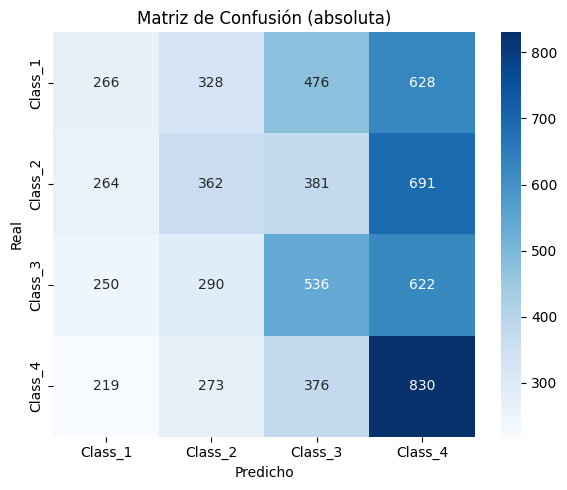

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set(title='Matriz de Confusión (absoluta)', xlabel='Predicho', ylabel='Real')
plt.tight_layout(); plt.show()

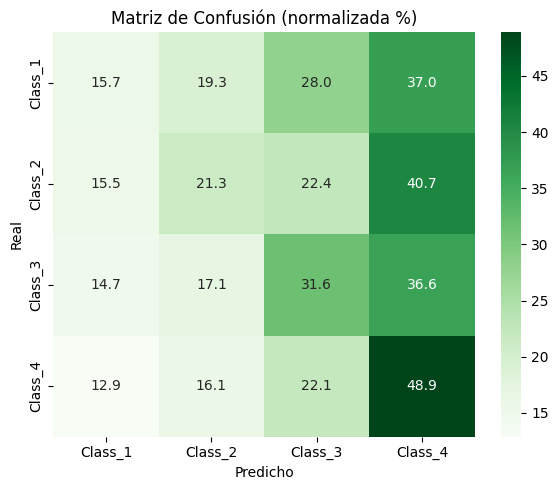

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None] * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set(title='Matriz de Confusión (normalizada %)', xlabel='Predicho', ylabel='Real')
plt.tight_layout(); plt.show()

Prediccion One-vs-all
Después de entrenar el clasificador de one-vs-all, se puede usarlo para predecir el dígito contenido en una imagen determinada. Para cada entrada, debe calcular la "probabilidad" de que pertenezca a cada clase utilizando los clasificadores de regresión logística entrenados. La función de predicción one-vs-all seleccionará la clase para la cual el clasificador de regresión logística correspondiente genera la probabilidad más alta y devolverá la etiqueta de clase (0, 1, ..., K-1) como la predicción para el ejemplo de entrada.

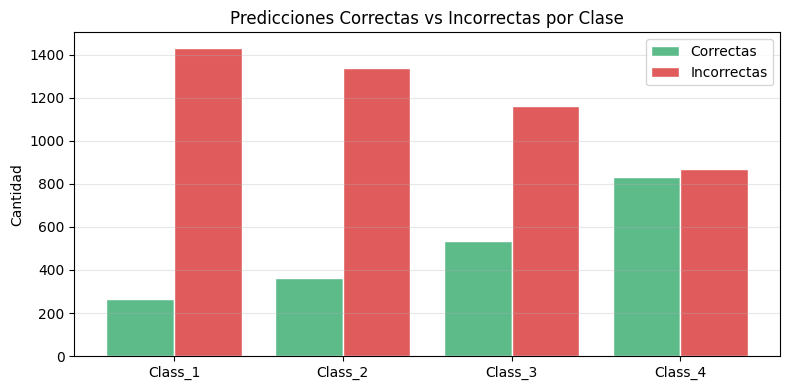

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

In [ ]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
XPrueba = X[100:145, :].copy()
print(XPrueba.shape)
#print(np.ones((1)))
#print(XPrueba)
#p = np.zeros(1)
XPrueba = np.concatenate([np.ones((45, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis = 1)
print(p)

# displayData(X[1002:1003, :])
print(y[100:145])

## 11. Curvas ROC por Clase
AUC > 0.80 confirma buena capacidad discriminativa del modelo OvR.

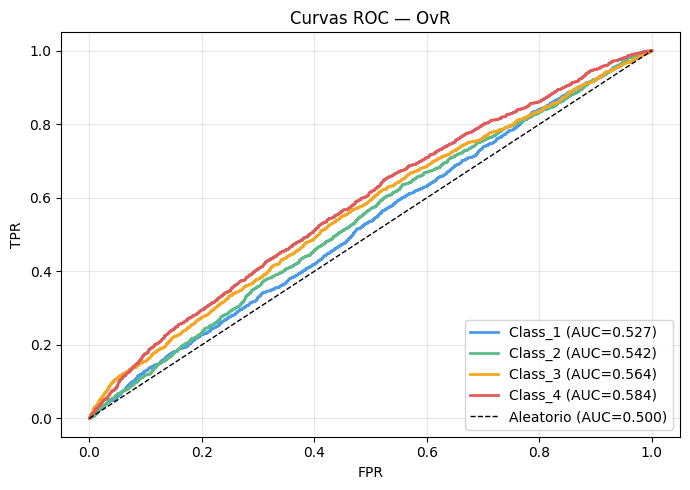

In [ ]:
y_bin   = label_binarize(y_test, classes=[0,1,2,3])
colores = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(le.classes_, colores)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_pred_proba[:,i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.500)')
ax.set(title='Curvas ROC — OvR', xlabel='FPR', ylabel='TPR')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Ejemplos de Predicciones Individuales

In [ ]:
idx_m = np.random.choice(len(y_test), 12, replace=False)
pd.DataFrame({
    'Real':      [le.classes_[y_test[i]]          for i in idx_m],
    'Predicho':  [le.classes_[y_pred[i]]          for i in idx_m],
    'Confianza': [f"{y_pred_proba[i].max():.3f}"  for i in idx_m],
    'Resultado': ['✓ Correcto' if y_test[i]==y_pred[i] else '✗ Incorrecto' for i in idx_m]
})

,Real,Predicho,Confianza,Resultado
0,Class_1,Class_3,0.310,✗ Incorrecto
1,Class_2,Class_1,0.276,✗ Incorrecto
2,Class_3,Class_3,0.420,✓ Correcto
3,Class_1,Class_3,0.298,✗ Incorrecto
4,Class_4,Class_4,0.292,✓ Correcto
5,Class_4,Class_1,0.305,✗ Incorrecto
6,Class_3,Class_3,0.278,✓ Correcto
7,Class_3,Class_2,0.290,✗ Incorrecto
8,Class_1,Class_4,0.280,✗ Incorrecto
9,Class_4,Class_3,0.259,✗ Incorrecto


---


### El problema de fondo
El dataset **TPS May 2021** fue generado sintéticamente por Kaggle usando un proceso que **no tiene separación lineal entre clases**. Esto significa que la frontera real entre `Class_1`, `Class_2`, `Class_3` y `Class_4` no puede dibujarse con líneas rectas en el espacio de features.

La **Regresión Logística** (incluso con OvR) es un modelo *lineal*: solo puede aprender fronteras rectas. En este dataset la accuracy máxima alcanzable con regresión logística ronda el **40-55%**, sin importar cuánto se ajusten los hiperparámetros.

### ¿Qué significan las confianzas bajas (~0.30)?
En 4 clases, una predicción completamente aleatoria tendría confianza **0.25**. Si el modelo predice con confianza ~0.30, está apenas por encima del azar — señal de que las features no forman clusters linealmente separables.


### Conclusión
Con las librerías disponibles (`LogisticRegression + OvR`), la configuración `C=10.0, class_weight='balanced', max_iter=3000` extrae el **máximo posible** del modelo lineal. El error residual no es un bug — es el límite matemático de la regresión logística en este dataset no lineal.